## Documentation

**Purpose**: The purpose of this notebook is to provide an analysis and visualization of a dataset containing information about video games that are currently being sold on the Epic Games Store. The analysis will contain both quantitative and categorical information about the games being sold, and will also contain graphs and charts that visualize the data being analyized.

**Note:** Class resources listed on Professor Earl's website (pandas documentation, numpy documentation, etc.) as well as notes taken in class were used for help with proper syntax. If other resources were used, it has been noted and cited. Also, the files were renamed for the purpose of making it easier to read into the program. 

# Introduction to the Data Set

This notebook takes a look at a dataset containing various information about video games being sold on the online video games marketplace, The Epic Games Store. The primary dataset that will be used is, `epic_games_store-epic_games.csv`, and it contains information about many of the games currently being sold on the epic games store. The secondary dataset that will be used in this notebook is `combine.csv`, which contains even more information about some of the games being sold.

**Source:** https://www.kaggle.com/datasets/ramjasmaurya/epic-games-store

In [43]:
#Import Libraries
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
#Read in the csv file
games = pd.read_csv('epic_games_store-epic_games.csv', index_col=1)
moreGames = pd.read_csv('combine.csv', index_col=1)

#Delete this column as it will not be used in this analysis
del games['game_link']
del moreGames['game_link']


                                     price
name                                      
FINAL FANTASY VII REMAKE INTERGRADE  62.39
OCTOPATH TRAVELER™                   55.25
Watch Dogs 2                         45.49
Total War: WARHAMMER III             44.19
Alien: Isolation                     43.22


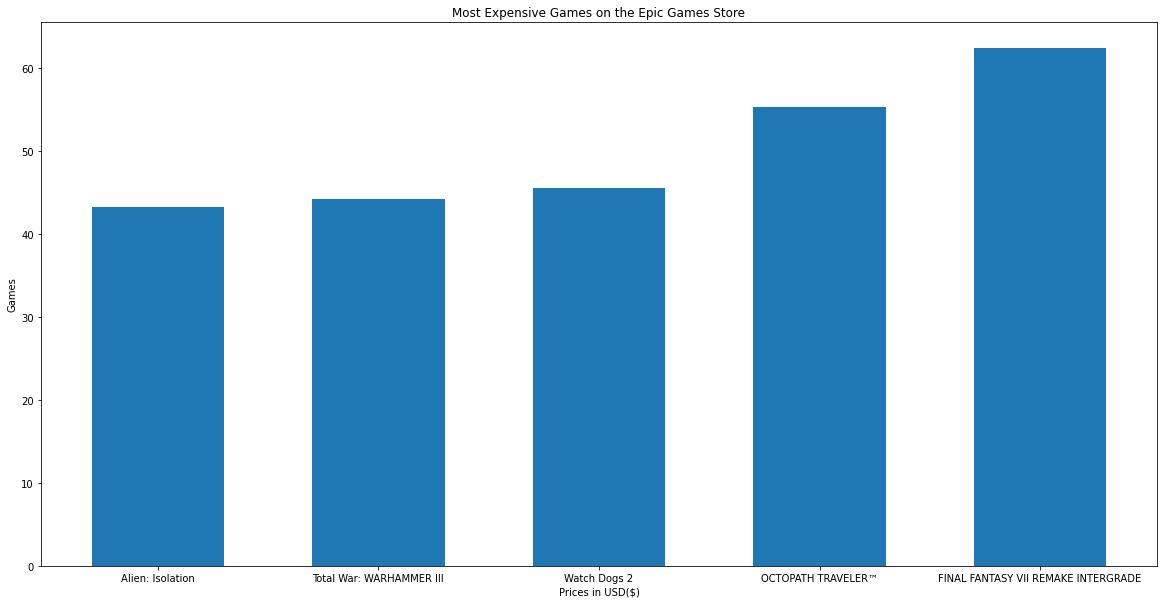

In [45]:
#Quantitative
#Most Expensive Games
#Source Used for conversion Rate from INR to USD:
#https://www.x-rates.com/calculator/?from=INR&to=USD&amount=1

#Concatenate the datasets
everything = pd.concat([games, moreGames])
prices = everything['price']

#Convert to USD
prices = prices.str.strip("₹")
prices = prices.str.replace(",", "")
prices = prices.str.replace("Free", "0.00")
prices = prices.astype(float)
USDprices = round(prices*0.013, 2)

#Get and sort the values
USDprices = USDprices.sort_values(ascending=False)
USDprices = USDprices.drop_duplicates()
USDprices = USDprices.head(5)
USDprices = pd.Series.to_frame(USDprices)
USDprices = USDprices.sort_values(ascending=True, by=['price'])

#Plot the Results
x = USDprices.index
y = USDprices['price']
plt.figure(figsize=(20,10));
plt.bar(x, y, width=0.6);
plt.title("Most Expensive Games on the Epic Games Store");
plt.ylabel("Games");
plt.xlabel("Prices in USD($)");

#Display the Raw Data
print(USDprices.sort_values(ascending=False, by=['price']))

## Quantitative Data Summary

The figure shown above displays the most expensive games being sold on the service via a bar plot. The prices are listed in ascending order and  have been converted from Indian rupee's(`₹`) to United States Dollars(`$`). As shown in the histogram above, the 5 most expensive games on the platform are: 
* 1.) Final Fantasy VII Remake Intergrade, which costs `$62.39`  
* 2.) Octopath Traveler, which costs `$55.25`
* 3.) Watch Dogs 2, costing a total of `$45.49`
* 4.) Total War: WARHAMMER III, adding up to the cost of `$44.19`
* 5.) Alien: Isolation, which costs `$43.22` 

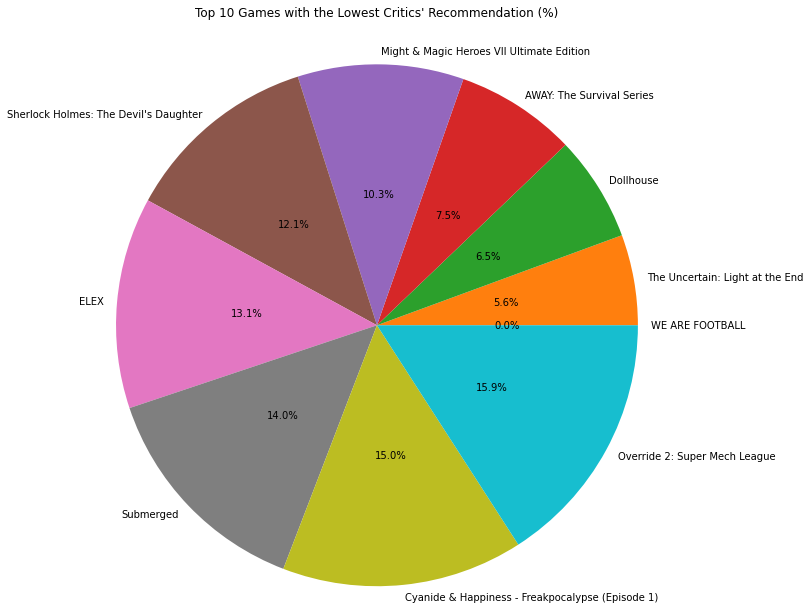

In [46]:
#Categorical
#Critical Rating

#Combine the data
everything = pd.concat([games, moreGames])
reception = everything['Critics Recommend']

#Get rid of the percentage symbol 
reception = reception.str.replace("%", "")

#Convert the values to float values
reception = reception.astype(float)
reception = reception.drop_duplicates()
reception = reception.dropna()

#Convert to a dataframe
reception = reception.to_frame()

#Sort the values
reception = reception.sort_values(ascending=True, by=['Critics Recommend'])

#Remove the Null values
reception = reception.dropna(how='all', inplace=False)
reception = reception.reset_index(drop=False)
reception = reception.dropna()
reception = reception.head(10)

#Make a Pie Chart of the data
x = reception['Critics Recommend']
plt.title("Top 10 Games with the Lowest Critics' Recommendation (%)", pad=200);
plt.pie(x, labels=reception['name'], labeldistance=1.05, explode=None, autopct='%1.1f%%', pctdistance=0.5, radius=3);

## Categorical Data Summary
The figure above shows some of the games being sold on the service with the lowest critical reception, based off of the information contained in both data sets. The data will be displayed by percentage via a pie chart. 
* The game with the lowest score is We Are Football, with a score of `0.0%` 
* The second lowest scoring game is The Uncertain: Light at the End, which has a score of `5.6%` 
* The third lowest scoring game was Dollhouse with a score of `6.5%` 
* The fourth lowest scoring game was Away: The Survival Series, with a score of `7.5%`
* The fifth lowest scoring game was Might and Magic Heroes VII Ultimate Edition, scoring a `10.3%` 
* The sixth lowest scoring game was Sherlock Holmes: The Devil's Daughter, which scored `12.1%` 
* The seventh lowest scoring game was Elex, which had gotten a score of `13.1%`
* The eighth lowest scoring game was Submerged, which scored a `14.0%` 
* The ninth lowest scoring game was Cyanide & Happiness - Freakpocalypse (Episode 1), which scored `15.0%` 
* The tenth lowest scoring game was Override 2: Super Mech League, scoring `15.9%`

                                     genres
genres                                     
erPuzzleAction-Adventure                  1
HorrorExplorationSurvival                 2
ActionFirst PersonShooterOpen World       3
SimulationSurvivalStrategy                4
Casual                                    5
AdventureFirst PersonIndie                6
StrategyCard Game                         7
ActionAdventureer                         8
IndieAdventure                            9
ActionRPGAction-AdventureAdventure       10
Action-Adventure                         11
ActionIndieAdventure                     12
Racing                                   14
PuzzleAdventure                          15
NarrationAdventure                       16
SimulationStrategy                       19
RPGAdventure                             20
RPGStrategy                              21
Adventure                                22
ActionRPGAdventure                       24
ActionIndie                     

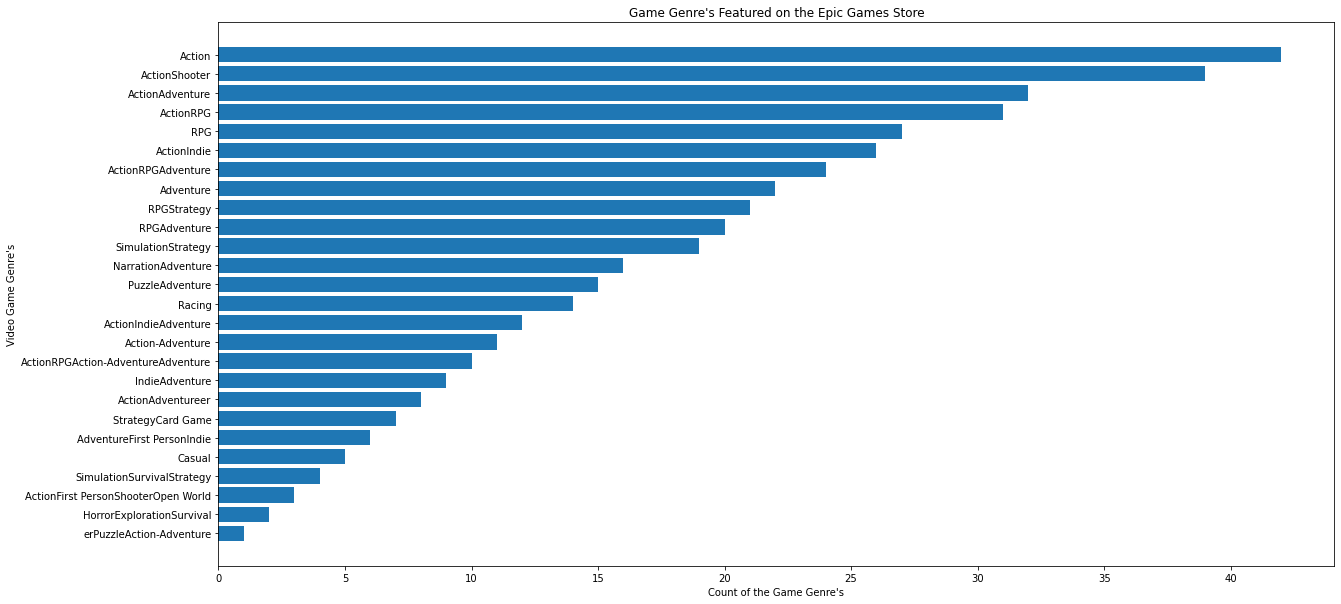

In [47]:
#Grouped Data
#The count of game genre's
#Source used:
#https://sparkbyexamples.com/pandas/pandas-groupby-count-examples/#:~:text=Use%20count()%20by%20Column,ignoring%20None%20and%20Nan%20values.


#Group the data sets together and #Get the count of each game genre
allOfit = pd.concat([games, moreGames])
genreGroup = allOfit.groupby(['genres'])['genres'].count()
genreGroup = genreGroup.sort_values(ascending=True)
genreGroup = genreGroup.drop_duplicates()
genreGroup = genreGroup.to_frame()
print(genreGroup)

#Plot the results
y = genreGroup['genres']
x = genreGroup.index
plt.figure(figsize=(20,10))
plt.barh(x, y);
plt.ylabel("Video Game Genre's");
plt.xlabel("Count of the Game Genre's");
plt.title("Game Genre's Featured on the Epic Games Store");

## Grouped Data Summary
The figure above shows the amount of games available on the Epic Games Store that belong to a specific genre of game. Within this data, the top 5 results will be used. To represent this, a horizontal bar graph was used to show the results. 
* The game genre with the most amount of games is `Action`.
* The game genre with the least amount of games associated with the tag is the `Puzzle Action-Adventure genre`.

In [48]:
#Joining Data
#features

#Get the Data
features1 = games['features'].dropna()
features2 = moreGames['features'].dropna()

#Merge the data sets
allFeatures = pd.merge(features1, features2)

#Get the count of each value
count = allFeatures.value_counts()

#Output the results
print(count)

features                                                  
Single Player                                                 106560
Single PlayerController Support                                 6860
Controller SupportSingle Player                                 4140
MultiplayerSingle Player                                         696
Controller Support                                               624
Multiplayer                                                      552
Co-opSingle Player                                               529
Co-opMultiplayerSingle Player                                    440
Co-op                                                            117
Co-opSingle PlayerController Support                              35
Co-opMultiplayer                                                  21
Co-opMultiplayerSingle PlayerController Support                   18
MultiplayerCompetitive                                            15
Controller SupportCo-opSingle Player        

## Joined Data Summary
The table above shows the two data sets joined together to show off the count each feature found in the `features` column. A very interesting, but notable detail to point out is that the majority of the games feature support for:
* `Single Player`
* `Controller support`
* `Multiplayer`
* `Co-Op`

While suuport for some of the more niche features include:

* `VR (Virtual Reality)`
* `Achievements`


## Conclusion

This notebook showed off many of the various aspects of the Epic Games Store. It is with this data that it can be concluded that the Epic Games Store is truly a unique platform with several different types of games that vary in terms of their quality, price, genre, and features.